In [1]:

!pip install transformers torch pandas scikit-learn matplotlib seaborn tqdm --quiet

In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
df = pd.read_csv("/content/drive/MyDrive/reviews.csv")

In [4]:
print("Sample Data:")
print(df.head())

Sample Data:
     brand                                        review_text
0  Samsung                Good for daily use, not for gaming.
1    Apple                Good for daily use, not for gaming.
2    Apple              The phone looks nice but feels heavy.
3  Samsung           Too many pre-installed apps (bloatware).
4    Apple  Apple ecosystem just works perfectly with my M...


In [5]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
sentiment_analyzer = pipeline("sentiment-analysis", model=model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [6]:
sentiments = []
for review in tqdm(df['review_text'], desc="Analyzing Sentiments"):
    result = sentiment_analyzer(review[:512])[0]  # Limit to 512 tokens
    sentiments.append(result)

Analyzing Sentiments: 100%|██████████| 2000/2000 [02:25<00:00, 13.79it/s]


In [7]:
df['sentiment_label'] = [s['label'] for s in sentiments]
df['sentiment_score'] = [s['score'] for s in sentiments]

In [8]:
df['sentiment_numeric'] = df['sentiment_label'].apply(lambda x: 1 if x == "POSITIVE" else -1)

In [9]:
brand_sentiment = df.groupby('brand')['sentiment_numeric'].mean().reset_index()
brand_sentiment.columns = ['Brand', 'Average Sentiment Score']

In [11]:
print("\n Average Sentiment Comparison:")
print(brand_sentiment)



 Average Sentiment Comparison:
     Brand  Average Sentiment Score
0    Apple                    0.350
1  Samsung                   -0.004


/tmp/ipython-input-2857985058.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_sentiment, x='Brand', y='Average Sentiment Score', palette='coolwarm')


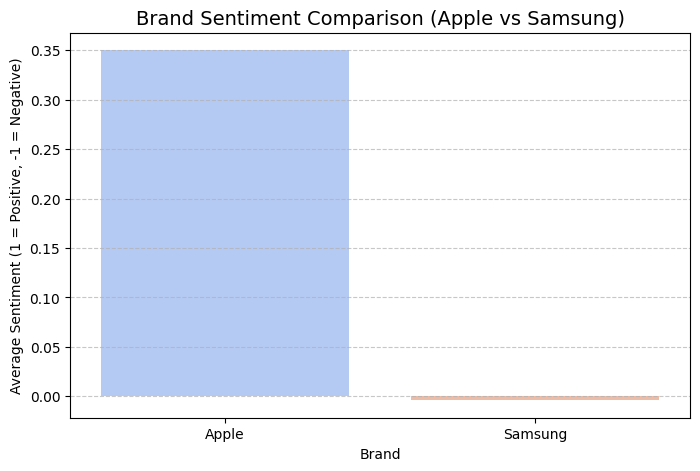

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=brand_sentiment, x='Brand', y='Average Sentiment Score', palette='coolwarm')
plt.title('Brand Sentiment Comparison (Apple vs Samsung)', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Average Sentiment (1 = Positive, -1 = Negative)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

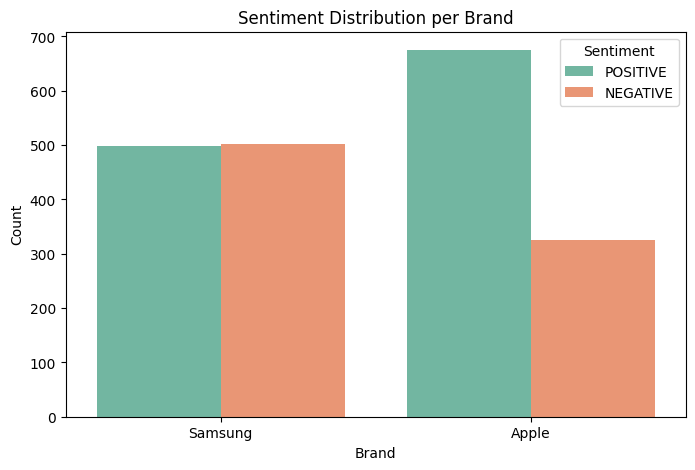

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='brand', hue='sentiment_label', palette='Set2')
plt.title('Sentiment Distribution per Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

In [ ]:
apple_avg = brand_sentiment.loc[brand_sentiment['Brand'] == 'Apple', 'Average Sentiment Score'].values[0]
samsung_avg = brand_sentiment.loc[brand_sentiment['Brand'] == 'Samsung', 'Average Sentiment Score'].values[0]

In [15]:
apple_avg = brand_sentiment.loc[brand_sentiment['Brand'] == 'Apple', 'Average Sentiment Score'].values[0]
samsung_avg = brand_sentiment.loc[brand_sentiment['Brand'] == 'Samsung', 'Average Sentiment Score'].values[0]

print("\n🔍 Insights:")
if apple_avg > samsung_avg:
    print(f"Apple reviews are generally more positive (score: {apple_avg:.2f}) compared to Samsung ({samsung_avg:.2f}).")
else:
    print(f"Samsung reviews are generally more positive (score: {samsung_avg:.2f}) compared to Apple ({apple_avg:.2f}).")


🔍 Insights:
Apple reviews are generally more positive (score: 0.35) compared to Samsung (-0.00).
